In [49]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns


In [50]:
# Q1
df = pd.read_csv('agriculture_yield_dataset.csv')
print("Rows and Columns:", df.shape)
print("\nColumn Names are: ",df.columns.tolist)
print("\nFirst 10 Records:",df.head(10))

Rows and Columns: (1500, 8)

Column Names are:  <bound method IndexOpsMixin.tolist of Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')>

First 10 Records:    rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8       

In [51]:
# Q2
print("Data Types of Each Column are:",df.dtypes)
print("\nMissing Values:",df.isnull().sum())
# No missing value present

Data Types of Each Column are: rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values: rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [52]:
# Q3
print("Summary Statistics:\n",df.describe)

print("\nFeature with Highest Mean:",df.describe().loc['mean'].idxmax(), "=",df.describe().loc['mean'].max())
print("\nFeature with Highest Standard Deviation:",df.describe().loc['std'].idxmax(), "=",df.describe().loc['std'].max())

Summary Statistics:
 <bound method NDFrame.describe of       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0           588.6           18.6          242.4               6.5      6.5   
1           772.8           34.6          247.2              10.0      6.5   
2           970.9           36.3          168.4               7.3      6.4   
3           611.7           19.0          121.7               3.7      6.0   
4           696.1           29.6          184.6               5.1      6.1   
...           ...            ...            ...               ...      ...   
1495        473.8           32.3           65.0               3.6      5.8   
1496        825.9           18.4          200.8               9.9      6.7   
1497        329.3           23.3           90.3               7.7      7.0   
1498        801.7           28.6          204.1               3.4      6.9   
1499        684.8           23.7           88.9               1.2      5.9   

     cro

In [53]:
# Q4
px.histogram(df,x='rainfall_mm',title='Distribution of Rainfall').show()

px.histogram(df,x='temperature_c',title='Distribution of Temperature').show()

px.histogram(df,x='fertilizer_kg',title='Distribution of Fertilizer').show()

px.histogram(df,x='yield_ton_per_hectare',title='Distribution of Yield').show()

# OBSERVATIONS

# RAINFALL :
   # Most rainfall values are spread across of wide range of values
   # There is no extreme skewness as such in the graph

# TEMEPERATURE :
   # Most temperature values are distributed between 20 and 35 degree celcius value
   # There is no skewness as such in the graph

# FERTILIZER :
   # Most Fertilizer usage values are spread across the graph evenly
   # There is no skewness as such in the graph

# YIELD :
   # The distribution appears to be of gaussian type
   # The majority of yield values are lying around the mean value

Number of records: 
 crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


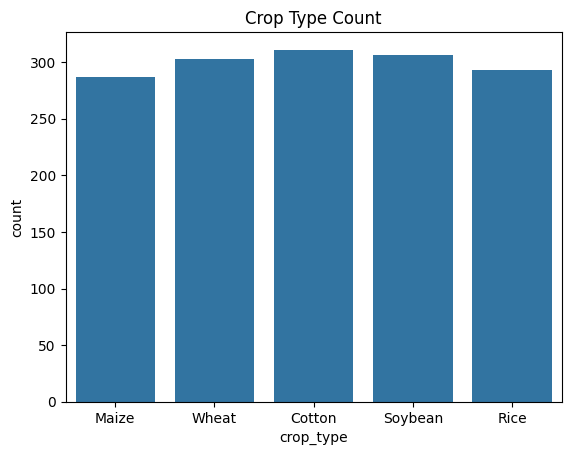

Most Frequent Crop: Cotton


In [54]:
# Q5
print("Number of records: \n",df['crop_type'].value_counts())

sns.countplot(data=df,x='crop_type')
plt.title('Crop Type Count')
plt.show()

print("Most Frequent Crop:",df['crop_type'].value_counts().idxmax())

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


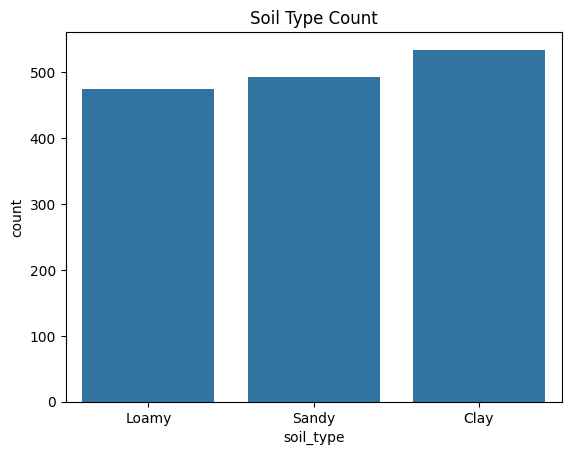

Most Common Soil Type: Clay


In [55]:
# Q6
print(df['soil_type'].value_counts())

sns.countplot(data=df,x='soil_type')
plt.title('Soil Type Count')
plt.show()

print("Most Common Soil Type:",df['soil_type'].value_counts().idxmax())

In [56]:
# Q7
px.histogram(df,x='yield_ton_per_hectare',title='Yield Distribution').show()

# Answers -
  # Yes, The histogram distribution is approximately normal
  # No, there are no significant outliers as seen from the graph

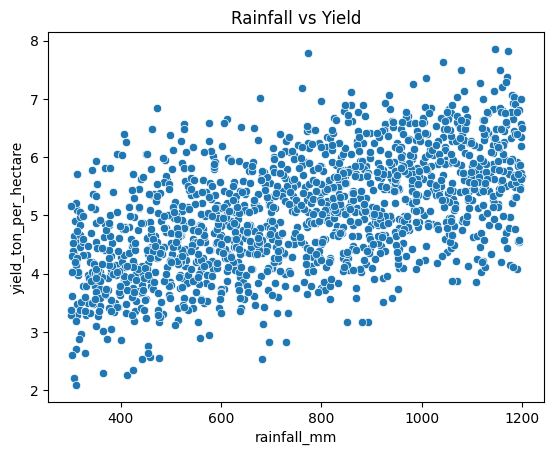

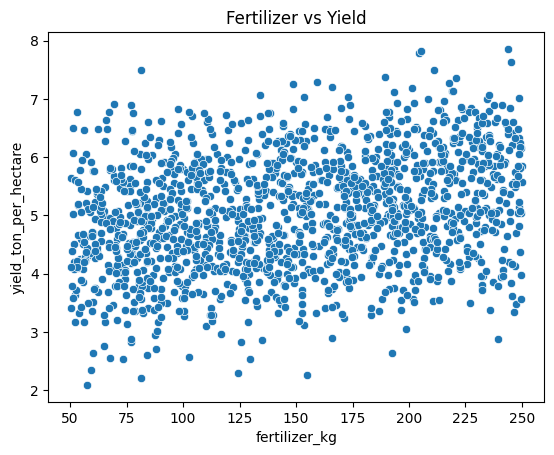

In [57]:
# Q8
sns.scatterplot(data=df,x='rainfall_mm',y='yield_ton_per_hectare')
plt.title('Rainfall vs Yield')
plt.show()

sns.scatterplot(data=df,x='fertilizer_kg',y='yield_ton_per_hectare')
plt.title('Fertilizer vs Yield')
plt.show()

# The rainfall feature is seen to have a more stronger relationship with the yield according to the graph

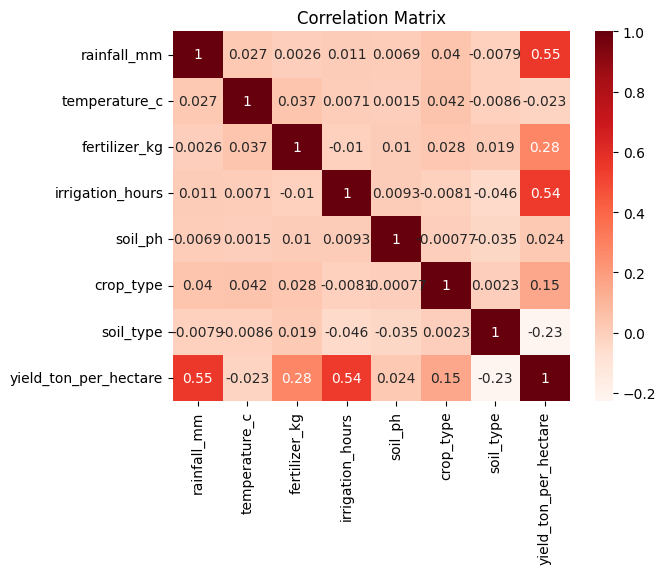

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
crop_type                0.154771
soil_ph                  0.024412
temperature_c           -0.022559
soil_type               -0.227301
Name: yield_ton_per_hectare, dtype: float64


In [58]:
# Q9
from sklearn.preprocessing import LabelEncoder

df2 = df.copy()
le = LabelEncoder()

df2['crop_type'] = le.fit_transform(df2['crop_type'])
df2['soil_type'] = le.fit_transform(df2['soil_type'])
corr_matrix = df2.corr()

sns.heatmap(corr_matrix,cmap='Reds',annot=True)
plt.title('Correlation Matrix')
plt.show()

yield_corr = corr_matrix['yield_ton_per_hectare'].sort_values(ascending=False)
print(yield_corr)

# The top three features are : rainfall_mm              0.553704
#                              irrigation_hours         0.542664
#                              fertilizer_kg            0.278043

In [59]:
# Q10
crop_yield = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
print(crop_yield)
print("Highest Average Yield Crop:",crop_yield.idxmax())
print()

soil_yield = df.groupby('soil_type')['yield_ton_per_hectare'].mean()
print(soil_yield)
print("Highest Average Yield Soil:",soil_yield.idxmax())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
Highest Average Yield Crop: Rice

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64
Highest Average Yield Soil: Loamy


In [60]:
# Q11

print("Categorical Columns",df.select_dtypes(include='object').columns)
print()
df_encoded = pd.get_dummies(df, columns=['crop_type','soil_type'])
print(df_encoded.head())


Categorical Columns Index(['crop_type', 'soil_type'], dtype='object')

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Cotton  crop_type_Maize  crop_type_Rice  \
0                   5.92             False             True           False   
1                   6.24             False             True           False   
2                   4.77             False            False           False   
3                   4.04             False             True           False   
4                   5.17              True            False           False   

   

In [61]:
# Q12
X = df_encoded.drop('yield_ton_per_hectare',axis=1)
y = df_encoded['yield_ton_per_hectare']

print("Target Variable Name:", y.name)

Target Variable Name: yield_ton_per_hectare


In [62]:
# Q13
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test :", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test :", y_test.shape)

Shape of X_train: (1200, 13)
Shape of X_test : (300, 13)
Shape of y_train: (1200,)
Shape of y_test : (300,)


In [63]:
# Q14
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

coeff = pd.DataFrame({'Feature': X.columns,'Coefficient': model.coef_})
coeff = coeff.sort_values(by='Coefficient',ascending=False)

print(coeff)
print("Intercept:")
print(model.intercept_)
print()


print("Feature having Highest Positive Coefficient feature:")
print(coeff.iloc[0])

              Feature  Coefficient
7      crop_type_Rice     0.477369
11    soil_type_Loamy     0.365627
3    irrigation_hours     0.198327
8   crop_type_Soybean     0.095096
10     soil_type_Clay     0.062653
2       fertilizer_kg     0.004978
4             soil_ph     0.004901
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
9     crop_type_Wheat    -0.038149
6     crop_type_Maize    -0.147693
5    crop_type_Cotton    -0.386623
12    soil_type_Sandy    -0.428280
Intercept:
1.9111026182800726

Feature having Highest Positive Coefficient feature:
Feature        crop_type_Rice
Coefficient          0.477369
Name: 7, dtype: object
